<a href="https://colab.research.google.com/github/siddhisalkar2005/CSL701-CE40_Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Siddhi Vitthal Salkar

Batch : CE3


Roll Number : CE40



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import sklearn libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv("data.csv")

# Display first 5 rows
df.head()

# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("data.csv")

# Check that data is loaded
print(df.shape)
df.head()

(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [ ]:
# Task 3: Data Cleaning and Feature/Target Selection

# 1. Drop unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32"])

# 2. Convert diagnosis into numerical values
# M = 1 (Malignant), B = 0 (Benign)
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# 3. Separate features (X) and target (y)
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# 4. Display the shapes
print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)

# 5. Display first 5 rows of X
print("\nFeatures (X):")
print(X.head())

# 6. Display first 5 values of y
print("\nTarget (y):")
print(y.head())

Feature matrix X shape: (569, 30)
Target vector y shape: (569,)

Features (X):
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_di

# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [ ]:
# Task 4: Standardize Features

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Fit the scaler and transform the features
X_scaled = scaler.fit_transform(X)

# Display the shape
print("Scaled feature matrix shape:", X_scaled.shape)

# Display first 5 rows
print("\nFirst 5 rows of scaled data:")
print(X_scaled[:5])

Scaled feature matrix shape: (569, 30)

First 5 rows of scaled data:
[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.4

# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [ ]:
# Task 5: Implement PCA (30D to 2D)

from sklearn.decomposition import PCA

# Create PCA object with 2 components
pca = PCA(n_components=2)

# Fit PCA and transform the scaled data
X_pca = pca.fit_transform(X_scaled)

# Display the shape
print("Original feature shape:", X_scaled.shape)
print("PCA feature shape:", X_pca.shape)

# Display first 5 rows
print("\nFirst 5 rows of PCA-transformed data:")
print(X_pca[:5])

Original feature shape: (569, 30)
PCA feature shape: (569, 2)

First 5 rows of PCA-transformed data:
[[ 9.19283683  1.94858307]
 [ 2.3878018  -3.76817174]
 [ 5.73389628 -1.0751738 ]
 [ 7.1229532  10.27558912]
 [ 3.93530207 -1.94807157]]


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [ ]:
# Task 6: Analyze Explained Variance Ratio

# Get explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Variance explained by PC1 and PC2
print("Variance explained by PC1:", explained_variance[0])
print("Variance explained by PC2:", explained_variance[1])

# Convert to percentage
print("\nPC1 Variance (%):", explained_variance[0] * 100)
print("PC2 Variance (%):", explained_variance[1] * 100)

# Calculate cumulative variance
cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative Variance:")
print(cumulative_variance)

print("\nTotal Variance Retained by PC1 + PC2:",
      cumulative_variance[-1] * 100, "%")

Variance explained by PC1: 0.44272025607526366
Variance explained by PC2: 0.18971182044033078

PC1 Variance (%): 44.272025607526366
PC2 Variance (%): 18.97118204403308

Cumulative Variance:
[0.44272026 0.63243208]

Total Variance Retained by PC1 + PC2: 63.243207651559445 %


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

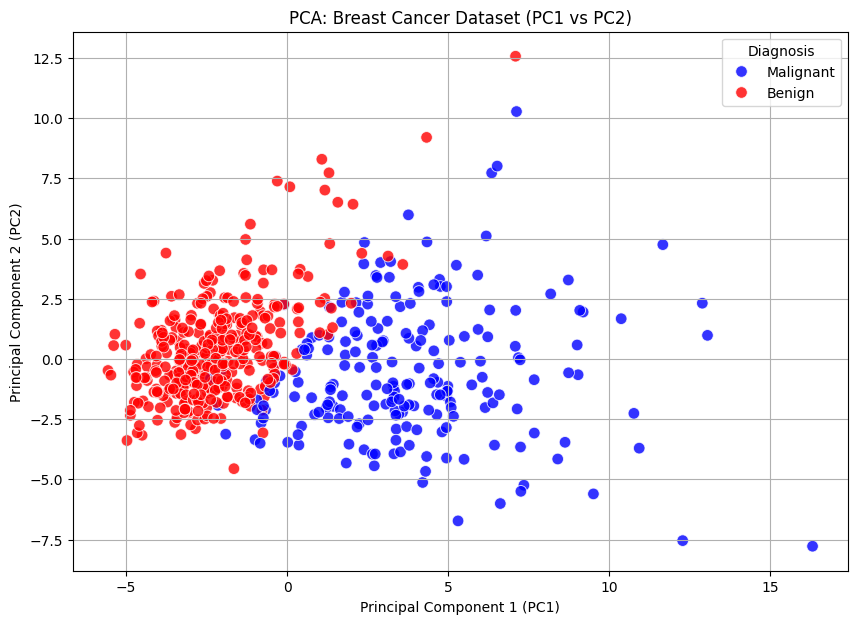

In [ ]:
# Task 7: Visualize PCA Transformed Data

# Create a DataFrame containing PCA results
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Add diagnosis labels
pca_df["Diagnosis"] = y.values

# Convert numerical labels back to names
pca_df["Diagnosis"] = pca_df["Diagnosis"].map({
    0: "Benign",
    1: "Malignant"
})

# Create scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    palette=["blue", "red"],
    s=70,
    alpha=0.8
)

plt.title("PCA: Breast Cancer Dataset (PC1 vs PC2)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Diagnosis")
plt.grid(True)
plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [ ]:
# Task 8: Train Classifier on Raw High-Dimensional Data

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# Split the scaled 30-feature data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Baseline Logistic Regression Performance")
print("-----------------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Complete classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"]
))

Baseline Logistic Regression Performance
-----------------------------------------
Accuracy : 0.9649122807017544
Precision: 0.975
Recall   : 0.9285714285714286

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [ ]:
# Task 9: Logistic Regression using PCA-transformed data

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# Split PCA data into training and testing sets
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
pca_model = LogisticRegression(max_iter=1000)

# Train the model
pca_model.fit(X_train_pca, y_train_pca)

# Make predictions
y_pred_pca = pca_model.predict(X_test_pca)

# Calculate performance metrics
pca_accuracy = accuracy_score(y_test_pca, y_pred_pca)
pca_precision = precision_score(y_test_pca, y_pred_pca)
pca_recall = recall_score(y_test_pca, y_pred_pca)

# Display results
print("PCA Logistic Regression Performance")
print("------------------------------------")
print("Accuracy :", pca_accuracy)
print("Precision:", pca_precision)
print("Recall   :", pca_recall)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_pca, y_pred_pca))

print("\nClassification Report:")
print(classification_report(
    y_test_pca,
    y_pred_pca,
    target_names=["Benign", "Malignant"]
))

PCA Logistic Regression Performance
------------------------------------
Accuracy : 0.9385964912280702
Precision: 0.972972972972973
Recall   : 0.8571428571428571

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [ ]:
# Task 10: Compare Classifier Performance

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
raw_accuracy = accuracy_score(y_test, y_pred)
pca_accuracy = accuracy_score(y_test_pca, y_pred_pca)

print("===== ACCURACY COMPARISON =====")
print("Before PCA (30 Features):", raw_accuracy)
print("After PCA (2 Components):", pca_accuracy)


# Confusion Matrix - Before PCA
print("\n===== CONFUSION MATRIX: BEFORE PCA =====")
print(confusion_matrix(y_test, y_pred))

# Confusion Matrix - After PCA
print("\n===== CONFUSION MATRIX: AFTER PCA =====")
print(confusion_matrix(y_test_pca, y_pred_pca))


# Classification Report - Before PCA
print("\n===== CLASSIFICATION REPORT: BEFORE PCA =====")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"]
))


# Classification Report - After PCA
print("\n===== CLASSIFICATION REPORT: AFTER PCA =====")
print(classification_report(
    y_test_pca,
    y_pred_pca,
    target_names=["Benign", "Malignant"]
))

===== ACCURACY COMPARISON =====
Before PCA (30 Features): 0.9649122807017544
After PCA (2 Components): 0.9385964912280702

===== CONFUSION MATRIX: BEFORE PCA =====
[[71  1]
 [ 3 39]]

===== CONFUSION MATRIX: AFTER PCA =====
[[71  1]
 [ 6 36]]

===== CLASSIFICATION REPORT: BEFORE PCA =====
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


===== CLASSIFICATION REPORT: AFTER PCA =====
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.